### Regression Model   22 September/2026

In [1]:
import numpy as np 
from statsmodels.api import OLS, add_constant 
import statsmodels.api as sm 

import seaborn as sns 

load_data = sm.datasets.get_rdataset("mtcars")
load_data = load_data.data 

In [2]:
load_data.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


- **What is heteroscedasticity?** 

Heteroscedasticity refers to the circumstance in which the variability of a variable is unequal across the range of values of a second variable that predicts it. In the context of regression analysis, it occurs when the variance of the errors is not constant across all levels of the independent variable(s). This can lead to inefficient estimates and affect the validity of statistical tests.
In simpler terms, if you plot the residuals of a regression model against the predicted values or an independent variable, heteroscedasticity is present if the spread of the residuals increases or decreases systematically with the predicted values. 

A common way to detect heteroscedasticity is through visual inspection of residual plots or by using statistical tests such as the Breusch-Pagan test or White test. Addressing heteroscedasticity often involves transforming the dependent variable, using robust standard errors, or applying weighted least squares regression.

In [3]:
# implement regression model 

X = add_constant(load_data[["wt", "hp"]]) 
y = load_data["mpg"] 
model = OLS(y, X).fit()
model.summary() 

print(model.params)
print(model.bse)  # print standard errors of the coefficients 
print(model.rsquared)  # print R-squared of the model
print(model.fvalue)  # print F-statistic of the model
print(model.pvalues)  # print p-values of the coefficients
print(model.conf_int())  # print confidence intervals of the coefficients
print(model.summary2())  # print detailed summary of the model

const    37.227270
wt       -3.877831
hp       -0.031773
dtype: float64
const    1.598788
wt       0.632733
hp       0.009030
dtype: float64
0.8267854518827914
69.2112133917777
const    2.565459e-20
wt       1.119647e-06
hp       1.451229e-03
dtype: float64
               0          1
const  33.957382  40.497158
wt     -5.171916  -2.583745
hp     -0.050241  -0.013305
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.815   
Dependent Variable: mpg              AIC:                154.6523
Date:               2026-09-22 18:31 BIC:                159.0495
No. Observations:   32               Log-Likelihood:     -74.326 
Df Model:           2                F-statistic:        69.21   
Df Residuals:       29               Prob (F-statistic): 9.11e-12
R-squared:          0.827            Scale:              6.7258  
-------------------------------------------------------------------
           Coef.    Std.Err.      t      P>|t|     

- Multicollinearity is: a situation in which two or more predictor variables in a regression model are highly correlated, leading to unreliable estimates of the regression coefficients.
- One way to detect multicollinearity is by examining the correlation matrix of the predictor variables. High correlation values (close to 1 or -1) indicate potential multicollinearity issues.  
- Another way to detect multicollinearity is by calculating the Variance Inflation Factor (VIF) for each predictor variable. A VIF value greater than 10 is often considered indicative of high multicollinearity.    
  

- The Durbin-Watson test is commonly used in regression analysis to check for autocorrelation in the residuals. 
a test statistic used to detect the presence of autocorrelation (a relationship between values separated from each other by a given time lag) in the residuals from a regression analysis. 
- The value of the Durbin-Watson statistic ranges from 0 to 4, with a value around 2 indicating no autocorrelation, values approaching 0 indicating positive autocorrelation, and values approaching 4 indicating negative autocorrelation. 

In [8]:
import pandas as pd
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = add_constant(load_data[["wt", "hp"]])
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data  

,feature,VIF
0,const,12.161539
1,wt,1.766625
2,hp,1.766625


In [11]:
load_data.columns.tolist()

['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']

In [12]:
import statsmodels.formula.api as smf
model_interaction = smf.ols('mpg ~ wt * hp', data=load_data).fit() 

print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     71.66
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           2.98e-13
Time:                        20:03:23   Log-Likelihood:                -67.805
No. Observations:                  32   AIC:                             143.6
Df Residuals:                      28   BIC:                             149.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.8084      3.605     13.816      0.0

In [ ]:
# # marginal effect of independent variables on the dependent variable  
# # implement marginal effect calculation for the regression model 

# model = sm.OLS(y, X).fit()  
# model_marginal_effect = model.get_margeff() 
# model_marginal_effect.summary() 

<Axes: >

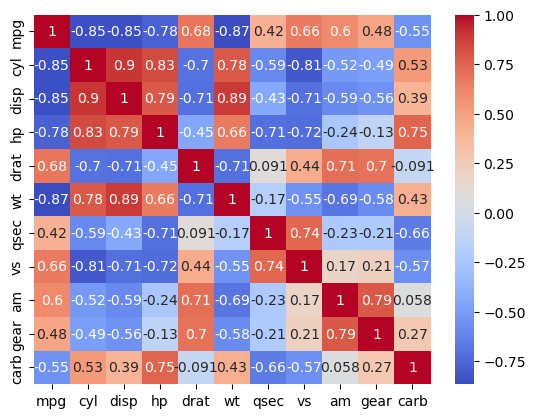

In [6]:
corr_matrix = load_data.corr()
corr_matrix
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")  # visualize the correlation matrix as a heatmap 

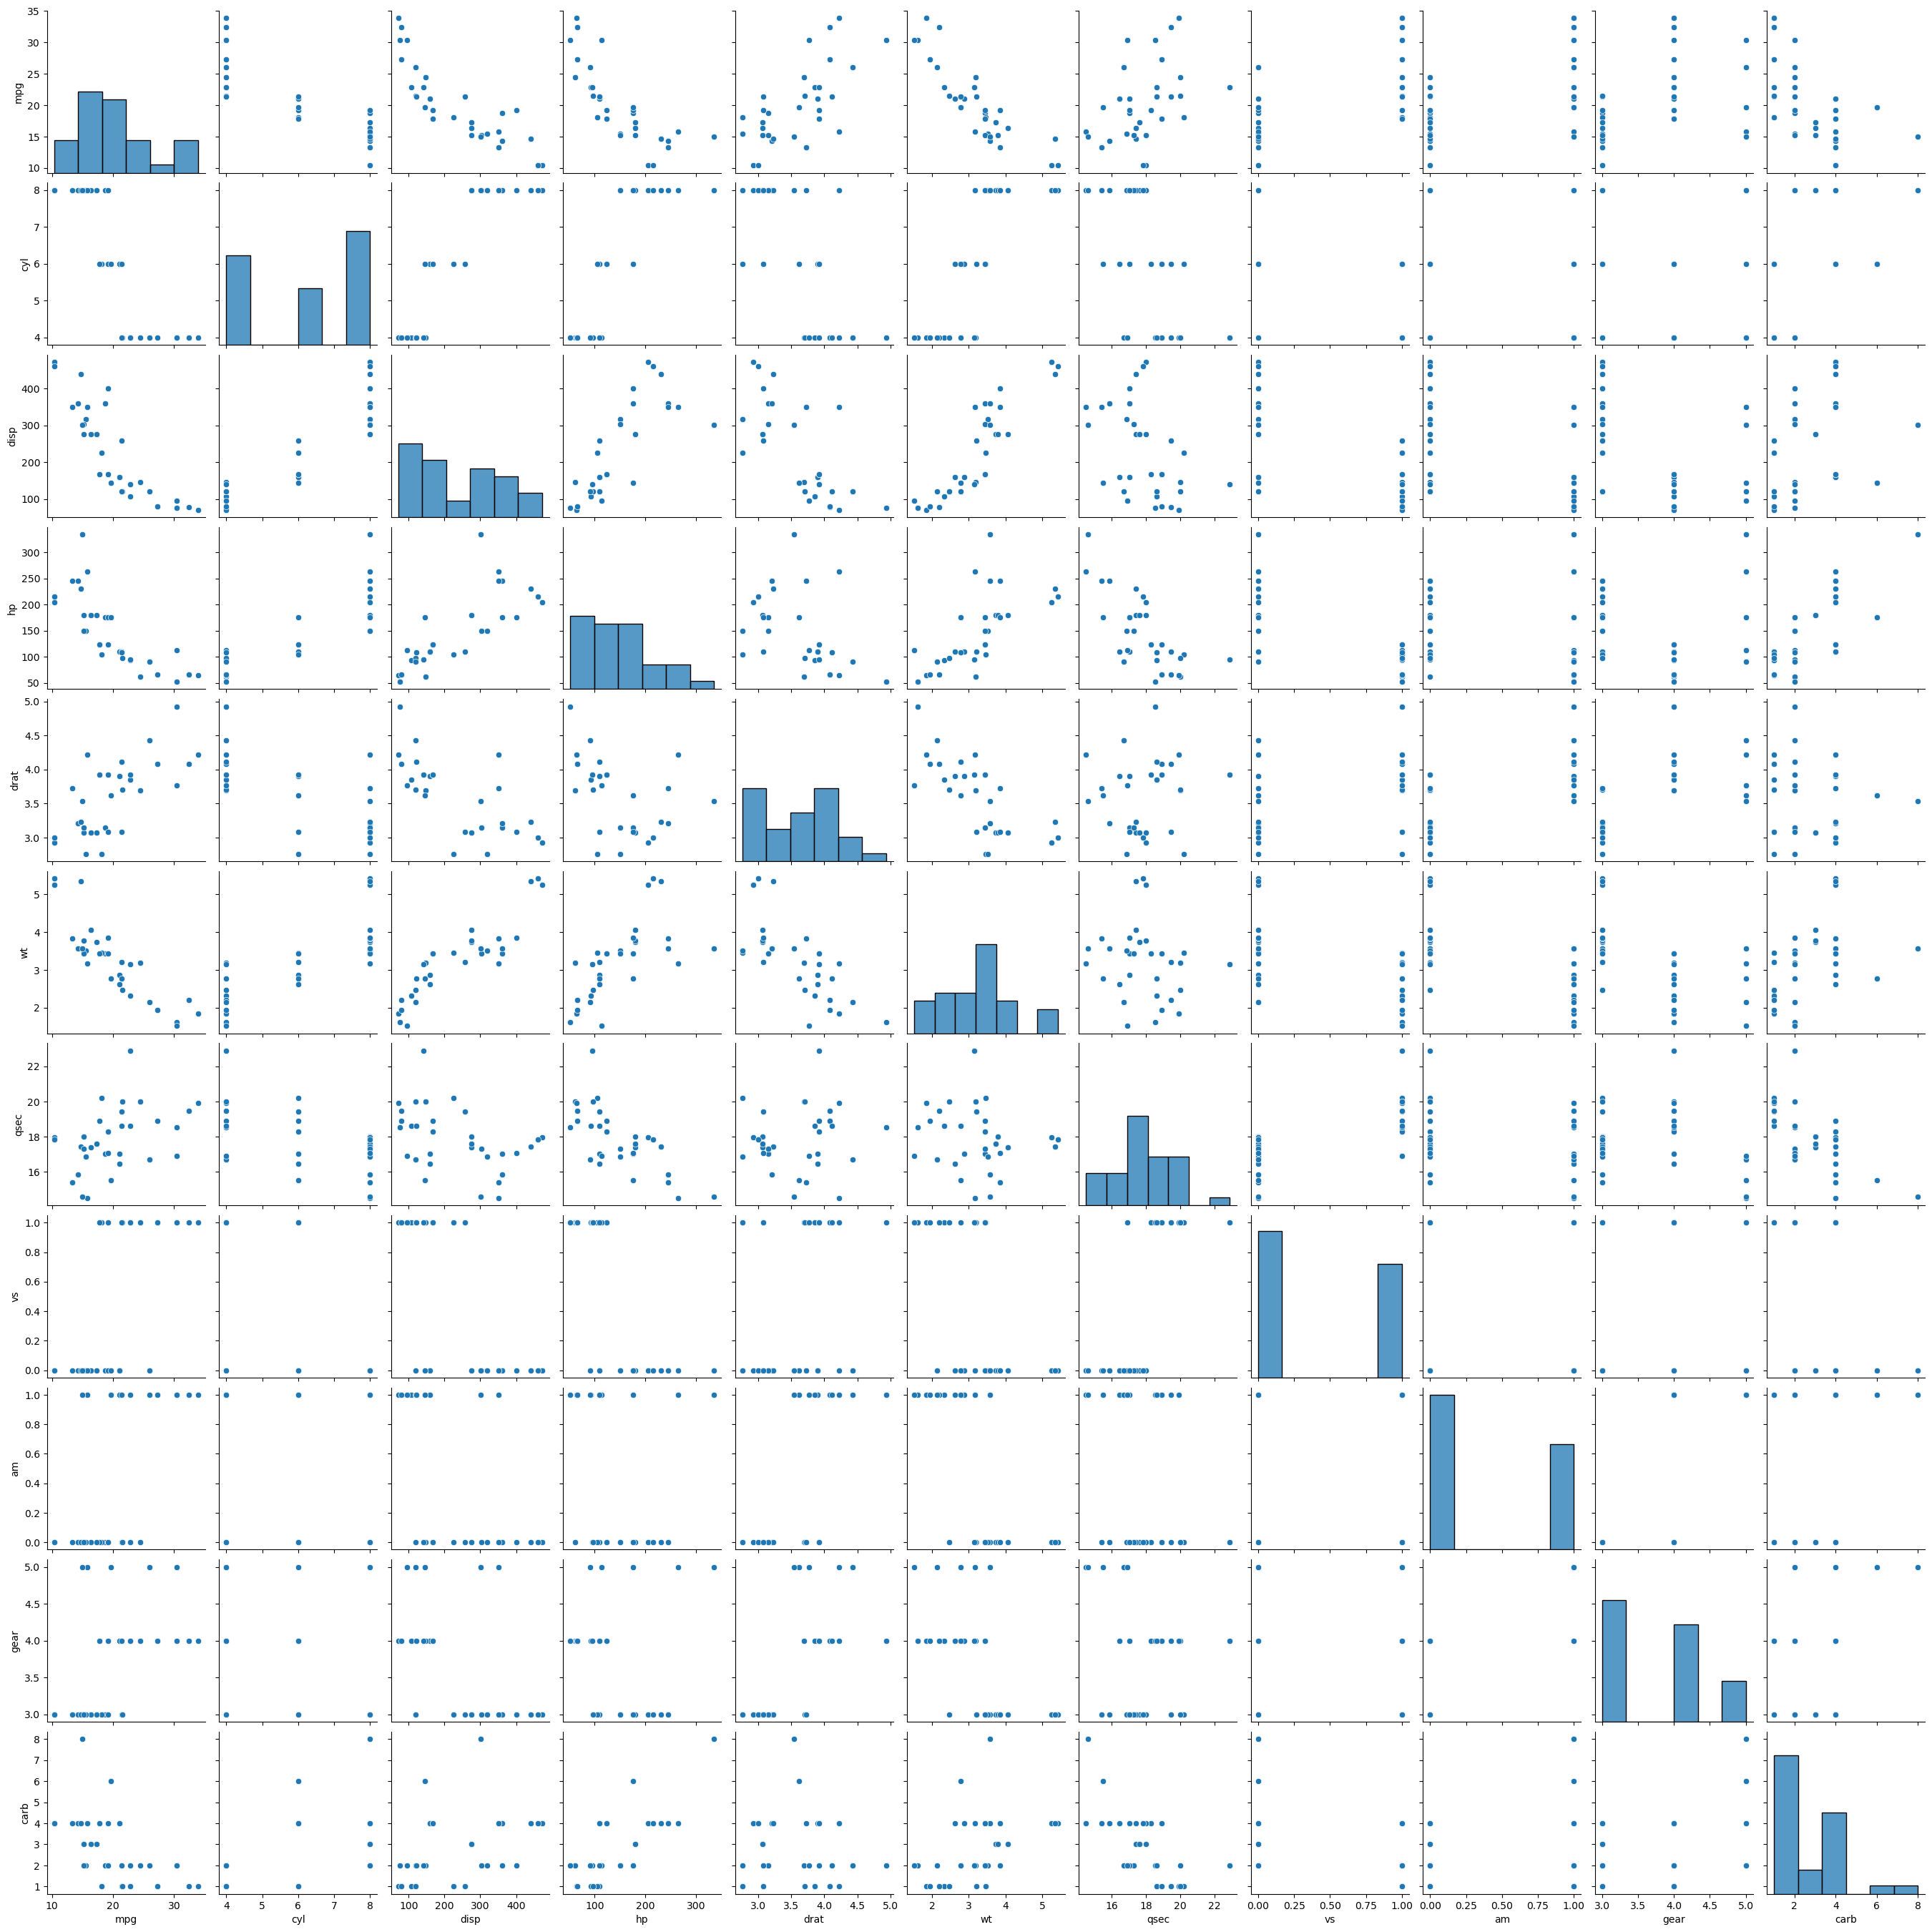

In [4]:
sns.pairplot(load_data) 

### Secon Order Model 

In [ ]:
# Concave: if regression model is second order and the coefficient of the second-order term is negative
# if regression model is second order and the coefficient of the second-order term is negative

# Convex: if the coefficient of the second-order term is positive 
# if the coefficient of the second-order term is positive 



# car dataset interaction terms correlation: